# LinkedIn Job Postings (2023 - 2024)

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import re
import nltk
import spacy 
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

In [3]:
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to C:\Users\Lenovo
[nltk_data]     T450\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Lenovo
[nltk_data]     T450\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Importación y exploración de los post

In [65]:
post = pd.read_csv("data/postings.csv")

In [142]:
post

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123844,3906267117,Lozano Smith,Title IX/Investigations Attorney,Our Walnut Creek office is currently seeking a...,195000.0,YEARLY,"Walnut Creek, CA",56120.0,1.0,NaN,...,NaN,1.713571e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,94595.0,6013.0
123845,3906267126,Pinterest,"Staff Software Engineer, ML Serving Platform",About Pinterest:\n\nMillions of people across ...,NaN,NaN,United States,1124131.0,3.0,NaN,...,NaN,1.713572e+12,www.pinterestcareers.com,0,FULL_TIME,NaN,NaN,NaN,NaN,NaN
123846,3906267131,EPS Learning,"Account Executive, Oregon/Washington",Company Overview\n\nEPS Learning is a leading ...,NaN,NaN,"Spokane, WA",90552133.0,3.0,NaN,...,NaN,1.713572e+12,epsoperations.bamboohr.com,0,FULL_TIME,NaN,NaN,NaN,99201.0,53063.0
123847,3906267195,Trelleborg Applied Technologies,Business Development Manager,The Business Development Manager is a 'hunter'...,NaN,NaN,"Texas, United States",2793699.0,4.0,NaN,...,NaN,1.713573e+12,NaN,0,FULL_TIME,NaN,NaN,NaN,NaN,NaN


In [67]:
post.info()

<class 'pandas.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  str    
 2   title                       123849 non-null  str    
 3   description                 123842 non-null  str    
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   str    
 6   location                    123849 non-null  str    
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  str    
 12  applies                     23320 non-null   float64
 13  original_listed_time     

In [143]:
post = post[['job_id', 'company_name', 'title', 'description','location','company_id','views','formatted_work_type','work_type']]

Primero vamos a filtrar las ofertas con el título "Data Analyst" en el csv, vamos a encontrar las vacantes con esta palabra.

In [144]:
post_data_analyst = post[post.title.str.contains('data analyst', case = False, na = False )]

In [145]:
post_data_analyst.info()

<class 'pandas.DataFrame'>
Index: 408 entries, 389 to 122747
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               408 non-null    int64  
 1   company_name         406 non-null    str    
 2   title                408 non-null    str    
 3   description          408 non-null    str    
 4   location             408 non-null    str    
 5   company_id           406 non-null    float64
 6   views                402 non-null    float64
 7   formatted_work_type  408 non-null    str    
 8   work_type            408 non-null    str    
dtypes: float64(2), int64(1), str(6)
memory usage: 1.3 MB


In [146]:
post_data_analyst.duplicated(subset=['job_id', 'title']).sum() # Esto implica que hay un total de 408 ofertas de trabajo únicas

np.int64(0)

Ahora que tenemos a las vacantes filtradas, vamos a unirlas con las job skills

In [147]:
# Exportamos los csv's correspondientes a las habilidades tanto a las abreviaciones como su significado
job_skills = pd.read_csv("data/jobs/job_skills.csv")
skills = pd.read_csv('data/mappings/skills.csv')
job_industries = pd.read_csv('data/jobs/job_industries.csv')
industries = pd.read_csv('data/mappings/industries.csv')
salaries = pd.read_csv('data/jobs/salaries.csv')

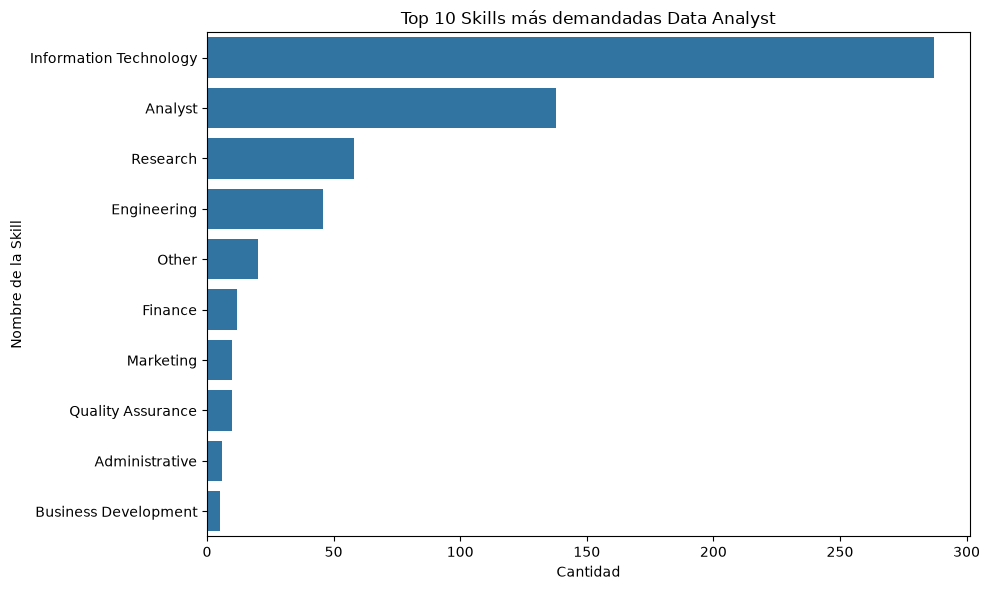

In [148]:
# Vamos a separar las skills en un solo DataFrame
skills_da = pd.merge(pd.merge(post_data_analyst, job_skills, on='job_id'), skills, on='skill_abr')
skills_da.shape # Tenemos ahora 616 registros implica que hay ofertas duplicadas
skills_da.duplicated(subset=['job_id']).sum() # Para ser exactos hay 211 filas duplicadas, esto tiene sentido pues hay más de una skill para algun post
# Como nos concierne ahora el analizar las skills nos quedaremos con job_id y el skill_name
skills_da = skills_da[['job_id', 'skill_name']]
#Ahora relicemos una suma de la aparición de cada skill y veamos graficamente sus respectivas frecuencias
skills_count = skills_da.skill_name.value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=skills_count.values, y=skills_count.index)
plt.title("Top 10 Skills más demandadas Data Analyst")
plt.xlabel("Cantidad")
plt.ylabel('Nombre de la Skill')
plt.tight_layout()
plt.savefig("imagenes/skills_da.png", )
plt.show()


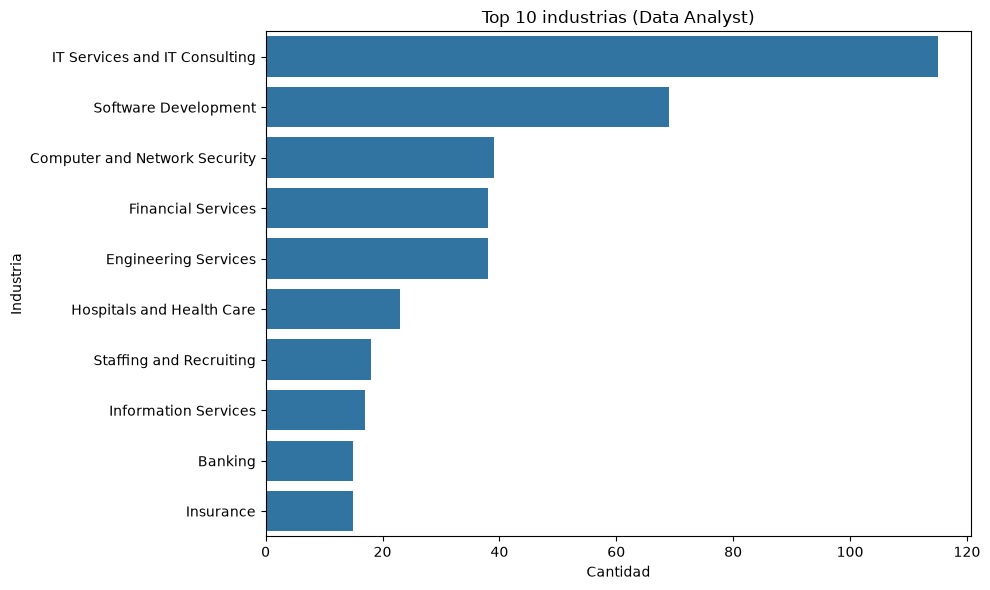

In [95]:
# Vamos a separar las industrias en un solo DataFrame
industries_da = pd.merge(pd.merge(post_data_analyst,job_industries, on='job_id'),industries, on='industry_id')
industries_da.shape # Tenemos ahora 578 registros implica que hay ofertas duplicadas 
industries_da.duplicated(subset=['job_id']).sum() # Para ser exactos hay 172 filas duplicadas, esto nos dice que hay más de una indsutria para algunos posts
# Como nos concierne ahora el analizar las industrias nos quedaremos con job_id y el industry_name
industries_da = industries_da[['job_id', 'industry_name']]
#Realicemos un Top 10 y grafiquemos
top_10_industries_da = industries_da['industry_name'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_10_industries_da.values, y=top_10_industries_da.index)
plt.title("Top 10 industrias (Data Analyst)")
plt.xlabel("Cantidad")
plt.ylabel('Industria')
plt.tight_layout()
plt.savefig("imagenes/top_in_da.png", )
plt.show()


Además vamos a ver cuales que tecnologías son más solicitadas en cada post, principalmente nos concentraremos en Excel, SQL, Python, R.

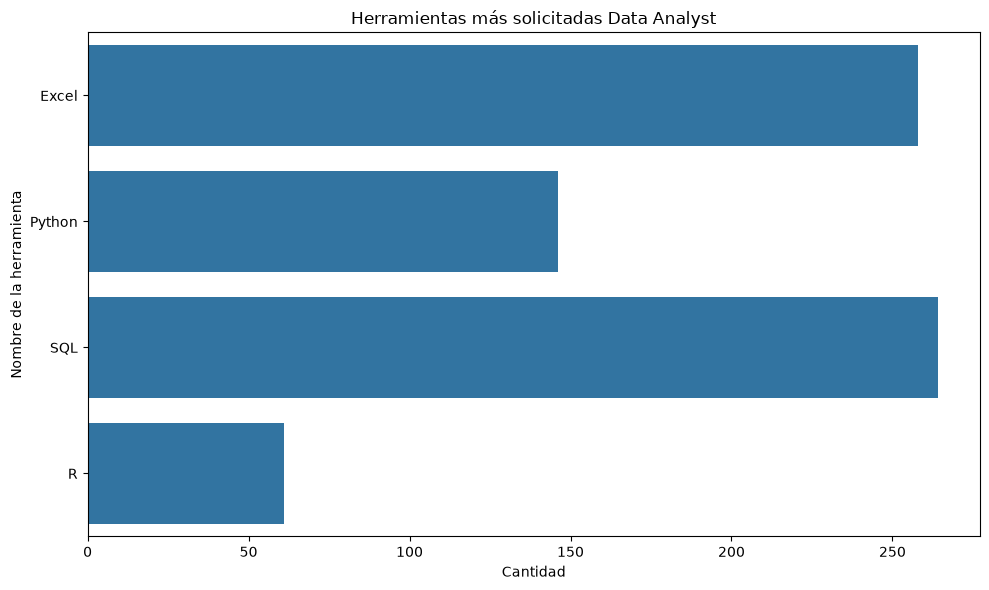

In [98]:
# Conteo de las tecnologias

tools_da = {'Excel': 0, 'Python': 0, 'SQL': 0, 'R': 0}
for tool in tools_da.keys():
    patron = rf'\b{tool.strip()}\b' if tool.strip() == 'R' else tool.strip()
    conteo = int(post_data_analyst['description'].str.contains(patron, case=False, na=False).sum())
    tools_da[tool] = conteo

# Creación del DataFrame

tools_data_analyst = pd.DataFrame.from_dict(tools_da, orient='index', columns=['count'])

# Gráfica
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=tools_data_analyst['count'], y=tools_data_analyst.index)
plt.title("Herramientas más solicitadas Data Analyst")
plt.xlabel("Cantidad")
plt.ylabel('Nombre de la herramienta')
plt.tight_layout()
plt.savefig('imagenes/tools_da.png')
plt.show()

Vamos ahora a hacer un analisis similar pero para los post de las ofertas de "Data Scientist"

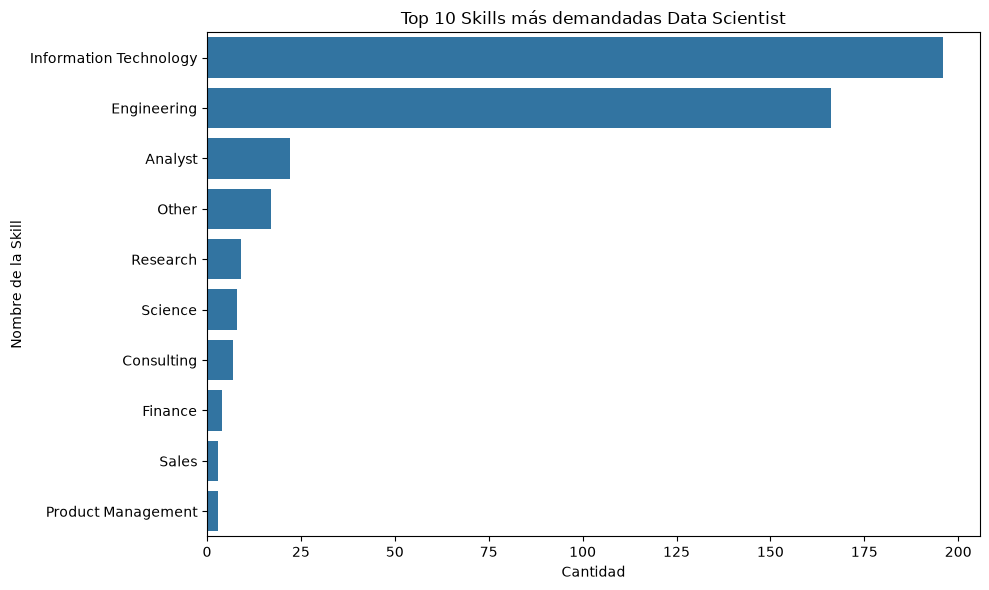

In [149]:
post_data_scientist = post[post.title.str.contains('data scient', case = False, na = False )] # Hay 247 posts
# Vamos a separar las skills en un solo DataFrame
skills_ds = pd.merge(pd.merge(post_data_scientist, job_skills, on='job_id'), skills, on='skill_abr')
skills_ds.shape # Tenemos ahora 452 registros implica que hay ofertas duplicadas
skills_ds.duplicated(subset=['job_id']).sum() # Para ser exactos hay 212 filas duplicadas, esto tiene sentido pues hay más de una skill para algun post
# Como nos concierne ahora el analizar las skills nos quedaremos con job_id y el skill_name
skills_ds = skills_ds[['job_id', 'skill_name']]
#Ahora relicemos una suma de la aparición de cada skill y veamos graficamente sus respectivas frecuencias
skills_count2 = skills_ds.skill_name.value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=skills_count2.values, y=skills_count2.index)
plt.title("Top 10 Skills más demandadas Data Scientist")
plt.xlabel("Cantidad")
plt.ylabel('Nombre de la Skill')
plt.tight_layout()
plt.savefig("imagenes/skills_ds.png", )
plt.show()


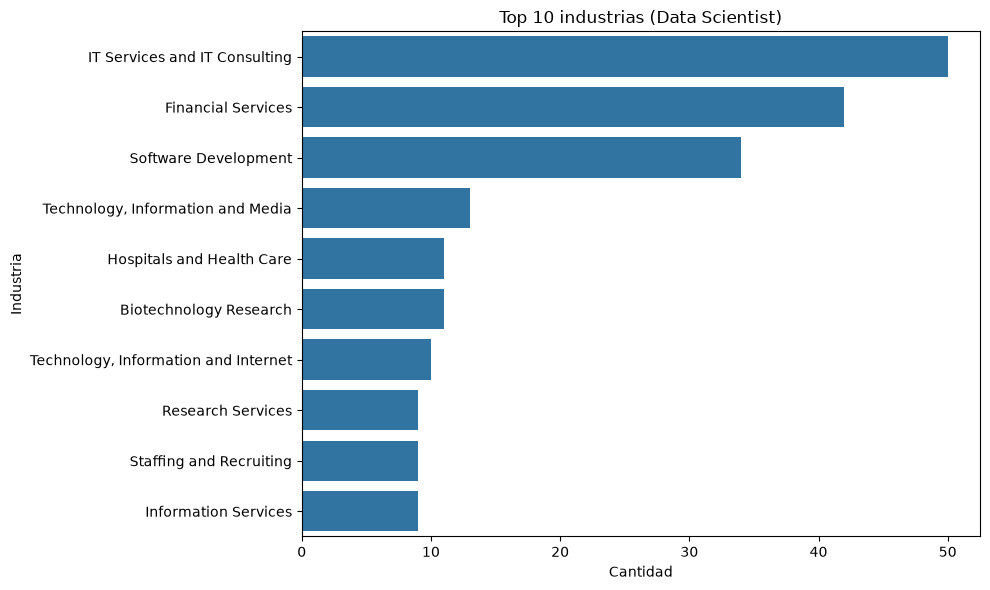

In [109]:
# Vamos a separar las industrias en un solo DataFrame
industries_ds = pd.merge(pd.merge(post_data_scientist,job_industries, on='job_id'),industries, on='industry_id')
industries_ds.shape # Tenemos ahora 321 registros implica que hay ofertas duplicadas 
industries_ds.duplicated(subset=['job_id']).sum() # Para ser exactos hay 75 filas duplicadas, esto nos dice que hay más de una indsutria para algunos posts
# Como nos concierne ahora el analizar las industrias nos quedaremos con job_id y el industry_name
industries_ds = industries_ds[['job_id', 'industry_name']]
#Realicemos un Top 10 y grafiquemos
top_10_industries_ds = industries_ds['industry_name'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_10_industries_ds.values, y=top_10_industries_ds.index)
plt.title("Top 10 industrias (Data Scientist)")
plt.xlabel("Cantidad")
plt.ylabel('Industria')
plt.tight_layout()
plt.savefig("imagenes/top_in_ds.png", )
plt.show()


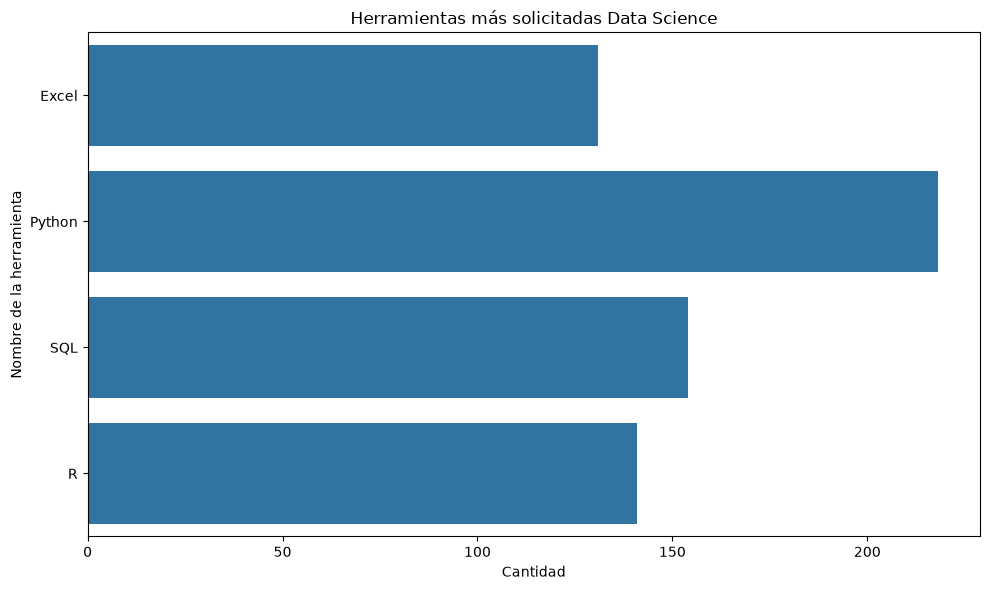

In [111]:
# Conteo de las tecnologias

tools_ds = {'Excel': 0, 'Python': 0, 'SQL': 0, 'R': 0}
for tool in tools_ds.keys():
    patron = rf'\b{tool.strip()}\b' if tool.strip() == 'R' else tool.strip()
    conteo = int(post_data_scientist['description'].str.contains(patron, case=False, na=False).sum())
    tools_ds[tool] = conteo

# Creación del DataFrame

tools_data_science = pd.DataFrame.from_dict(tools_ds, orient='index', columns=['count'])

# Gráfica
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=tools_data_science['count'], y=tools_data_science.index)
plt.title("Herramientas más solicitadas Data Science")
plt.xlabel("Cantidad")
plt.ylabel('Nombre de la herramienta')
plt.tight_layout()
plt.savefig('imagenes/tools_ds.png')
plt.show()

# Analisis de las descripciones de cada post

In [112]:
# Definir la Stopwords
stopwords = set(nltk.corpus.stopwords.words('english')) 
nlp = spacy.load("en_core_web_sm")

#Limpieza de los posts
def post_cleaner(text):
    # Primero pasamos todas las letras a minúsculas
    text = text.lower()
    # Eliminamos los caracteres inecesarios
    patron = r'[^\w\s]'
    text = re.sub(patron, ' ', text)
    return text
 
#Eliminar las Stop Word
def stop_tok_lem(text):
    #Primero tokenizamos
    tok = word_tokenize(text)
    stop = [word for word in tok if word.isalnum() and word not in stopwords]
    text = ' '.join(stop)
    #doc = nlp(text)
    #lem = [token.lemma_ for token in doc]
    #text = ' '.join(lem)
    return text


In [114]:
# Procedemos a aplicar las funciones sobre la descrpción de cada post
post_data_analyst['desc_clean'] = post_data_analyst['description'].apply(post_cleaner)
post_data_analyst['desc_clean'] = post_data_analyst['desc_clean'].apply(stop_tok_lem)

# Juntamos todos los posts para crear la nube

texto_para_nube = ' '.join(post_data_analyst['desc_clean'])

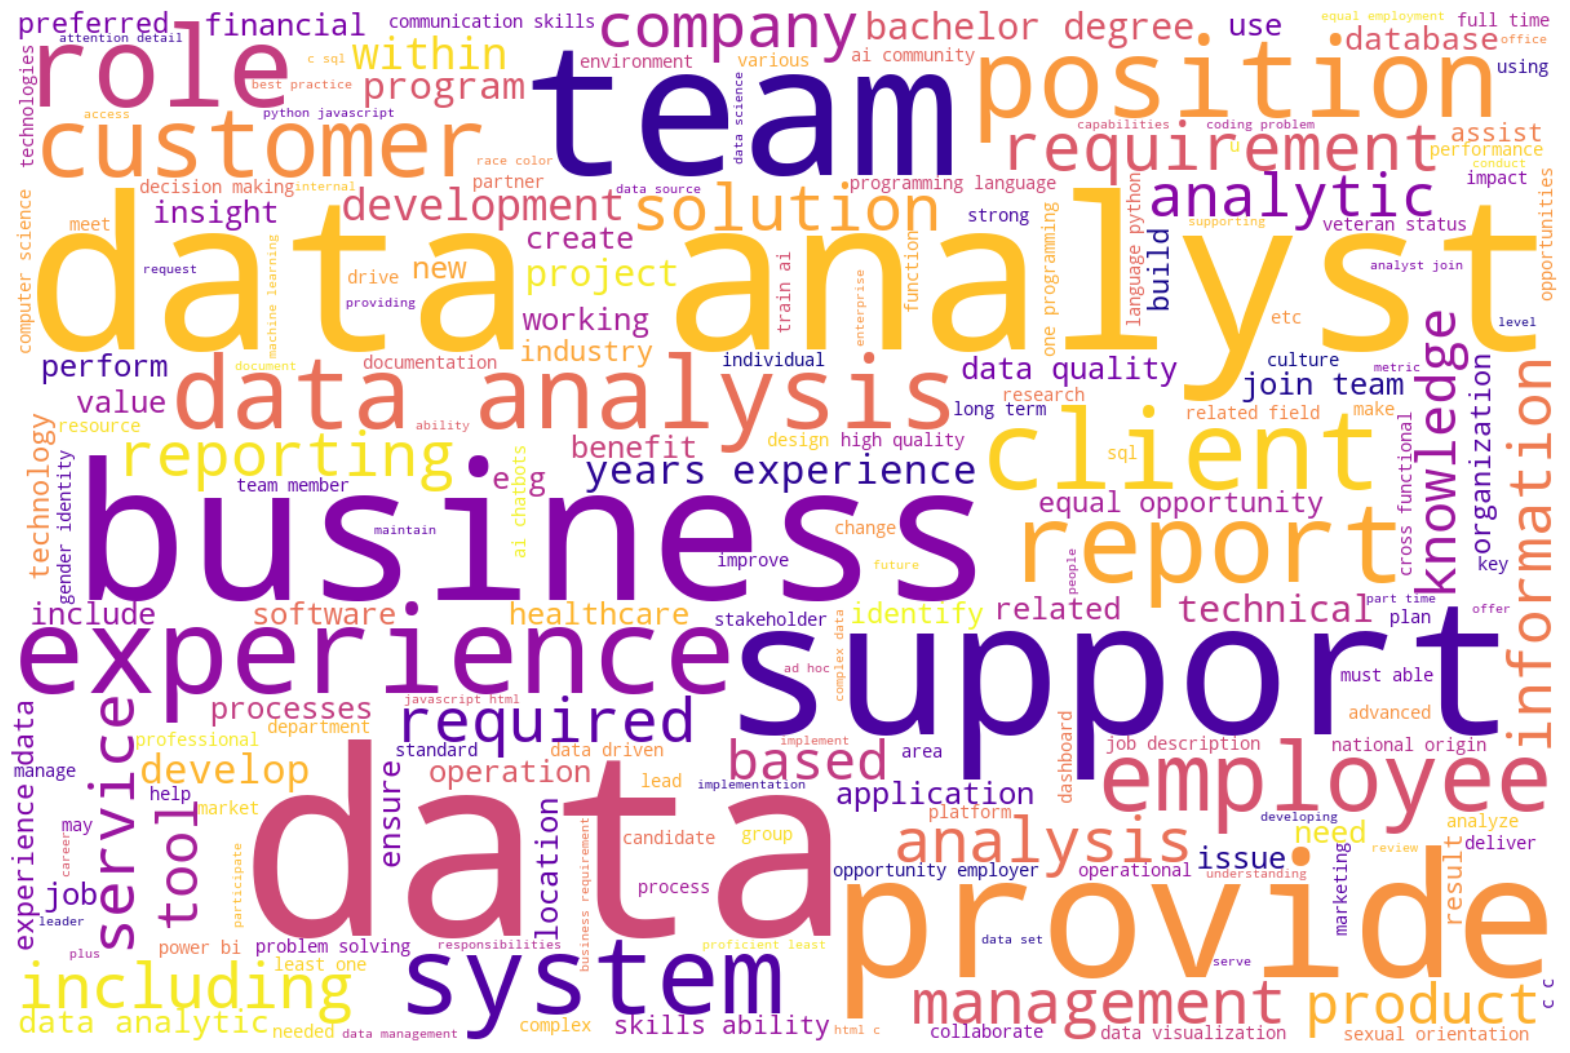

In [119]:
nube = WordCloud(
    width=1200, 
    height=800,
    background_color='white',       
    colormap='plasma',              
    max_words=200,                  
    max_font_size=200,              
    prefer_horizontal=0.85 ).generate(texto_para_nube)

plt.figure(figsize=(20,20))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.savefig('imagenes/wc_da.png')
plt.show()

Vamos a hacer lo mismo para los post de Data Scientist

In [117]:
# Procedemos a aplicar las funciones sobre la descrpción de cada post
post_data_scientist['desc_clean'] = post_data_scientist['description'].apply(post_cleaner)
post_data_scientist['desc_clean'] = post_data_scientist['desc_clean'].apply(stop_tok_lem)

# Juntamos todos los posts para crear la nube

texto_para_nube2 = ' '.join(post_data_scientist['desc_clean'])

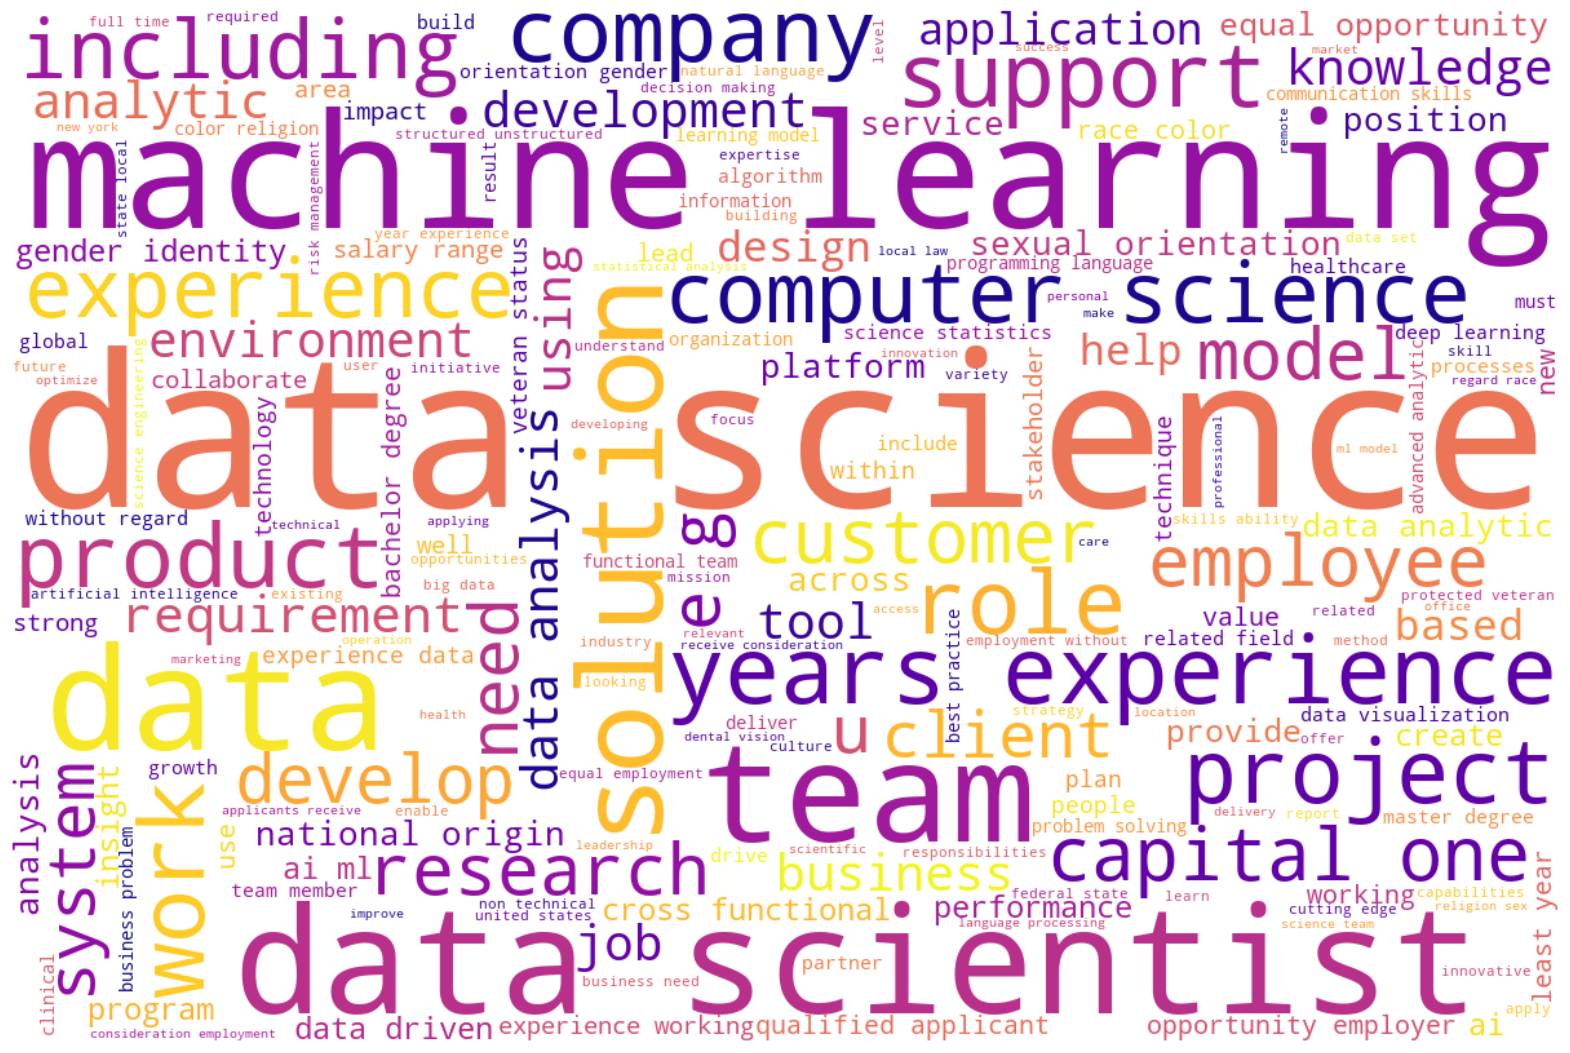

In [120]:
nube2 = WordCloud(
    width=1200, 
    height=800,
    background_color='white',       
    colormap='plasma',              
    max_words=200,                  
    max_font_size=200,              
    prefer_horizontal=0.85 ).generate(texto_para_nube2)

plt.figure(figsize=(20,20))
plt.imshow(nube2, interpolation="bilinear")
plt.axis("off")
plt.savefig('imagenes/wc_ds.png')
plt.show()